# 02427 Advanced Time Series Analysis — Computer Exercise 1, Parts 1–2



* **Part 1** – simulate SETAR(2;1;1), IGAR(2;1), MMAR(2;1) with two parameter sets each.
* **Part 2** – theoretical conditional mean of a SETAR(2;1;1), local-regression estimates with different bandwidths, leave-one-out (LOO) bandwidth.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})
for d in ["Images/part-1", "Images/part-2", "Images/part-3"]:
    os.makedirs(d, exist_ok=True)

def save(fig, path):
    fig.savefig(path, bbox_inches="tight")
    print("saved ->", path)

C1, C2 = "#1f77b4", "#d62728"   # regime colours

## Part 1 — Simulation of three non-linear regime models

All three models are *regime-switching AR(1)* models with two regimes:

$$X_t = a_0^{(J_t)} + a_1^{(J_t)} X_{t-1} + \varepsilon_t^{(J_t)},\qquad \varepsilon_t^{(j)}\sim N(0,\sigma_j^2)\ \text{i.i.d.}$$

They only differ in **how the regime $J_t$ is chosen**:

| Model | Regime rule |
|---|---|
| SETAR(2;1;1) | $J_t=1$ if $X_{t-1}\le r$, else $J_t=2$ (self-exciting, deterministic given the past) |
| IGAR(2;1) | $J_t$ i.i.d., $P(J_t=1)=p$ (independent of everything) |
| MMAR(2;1) | $J_t$ is a hidden Markov chain with transition matrix $\mathbf P$ |

To make the comparison fair, **parameter set A** (the same AR coefficients in all three models) is

$$\text{regime 1: } X_t = 2 + 0.5X_{t-1} + \varepsilon_t,\qquad \text{regime 2: } X_t = -1 - 0.6X_{t-1} + \varepsilon_t,\quad \sigma=1.$$

In [2]:
def simulate_regime_ar(n, a0, a1, sigma, regime_rule, burn=500, seed=1, x0=0.0):
    '''Generic 2-regime AR(1) simulator.
    regime_rule(x_prev, j_prev, rng) -> regime index (0 or 1) at time t.'''
    rng = np.random.default_rng(seed)
    N = n + burn
    x = np.zeros(N); J = np.zeros(N, dtype=int)
    x[0] = x0
    e = rng.standard_normal(N)
    for t in range(1, N):
        j = regime_rule(x[t-1], J[t-1], rng)
        J[t] = j
        x[t] = a0[j] + a1[j] * x[t-1] + sigma[j] * e[t]
    return x[burn:], J[burn:]

# ---- regime rules ----
def setar_rule(r=0.0):
    return lambda xp, jp, rng: 0 if xp <= r else 1

def igar_rule(p):
    return lambda xp, jp, rng: 0 if rng.random() < p else 1

def mmar_rule(P):
    P = np.asarray(P)
    return lambda xp, jp, rng: 0 if rng.random() < P[jp, 0] else 1

def run_lengths(J):
    '''average length of consecutive runs in each regime'''
    changes = np.flatnonzero(np.diff(J)) + 1
    segs = np.split(J, changes)
    return {k+1: np.mean([len(s) for s in segs if s[0] == k]) for k in (0, 1)}

def describe(name, x, J):
    frac = [np.mean(J == 0), np.mean(J == 1)]
    rl = run_lengths(J)
    print(f"{name:32s} mean={x.mean():6.2f} sd={x.std():5.2f} "
          f"time in regime 1/2 = {frac[0]:.2f}/{frac[1]:.2f}   "
          f"mean run length 1/2 = {rl[1]:.1f}/{rl[2]:.1f}")

def three_panel(axrow, x, J, title, nshow=300):
    t = np.arange(nshow)
    ax = axrow[0]
    ax.plot(t, x[:nshow], color="0.6", lw=0.7)
    ax.scatter(t, x[:nshow], c=np.where(J[:nshow] == 0, C1, C2), s=6, zorder=3)
    ax.set_title(title + ": time series"); ax.set_xlabel("t"); ax.set_ylabel("$X_t$")
    ax = axrow[1]
    ax.scatter(x[:-1], x[1:], c=np.where(J[1:] == 0, C1, C2), s=4, alpha=0.5)
    ax.set_title("lag plot (colour = regime at $t$)")
    ax.set_xlabel("$X_{t-1}$"); ax.set_ylabel("$X_t$")
    ax = axrow[2]
    ax.hist(x, bins=60, density=True, color="0.5")
    ax.set_title("marginal density"); ax.set_xlabel("$X_t$")

n = 2000
a0A, a1A, sA = (2.0, -1.0), (0.5, -0.6), (1.0, 1.0)

### 1.1 SETAR(2;1;1)

$$X_t=\begin{cases}a_0^{(1)}+a_1^{(1)}X_{t-1}+\varepsilon_t & X_{t-1}\le r\\ a_0^{(2)}+a_1^{(2)}X_{t-1}+\varepsilon_t & X_{t-1}> r\end{cases}$$

* **Set A** (threshold $r=0$): regime 1 pushes the process up, regime 2 pushes it down ⇒ strong oscillation.
* **Set B** (threshold $r=0$): $X_t=-1+0.8X_{t-1}+1.5\varepsilon_t$ if $X_{t-1}\le0$, $X_t=1+0.8X_{t-1}+1.5\varepsilon_t$ otherwise. Each regime has its own stable equilibrium ($-5$ and $+5$) ⇒ two attractors, bimodal marginal density, and the process switches only when the noise pushes it across the threshold.

SETAR set A                      mean= -0.27 sd= 1.85 time in regime 1/2 = 0.53/0.47   mean run length 1/2 = 1.2/1.1
SETAR set B                      mean=  0.28 sd= 5.32 time in regime 1/2 = 0.48/0.52   mean run length 1/2 = 56.4/61.3
saved -> Images/part-1/setar.png


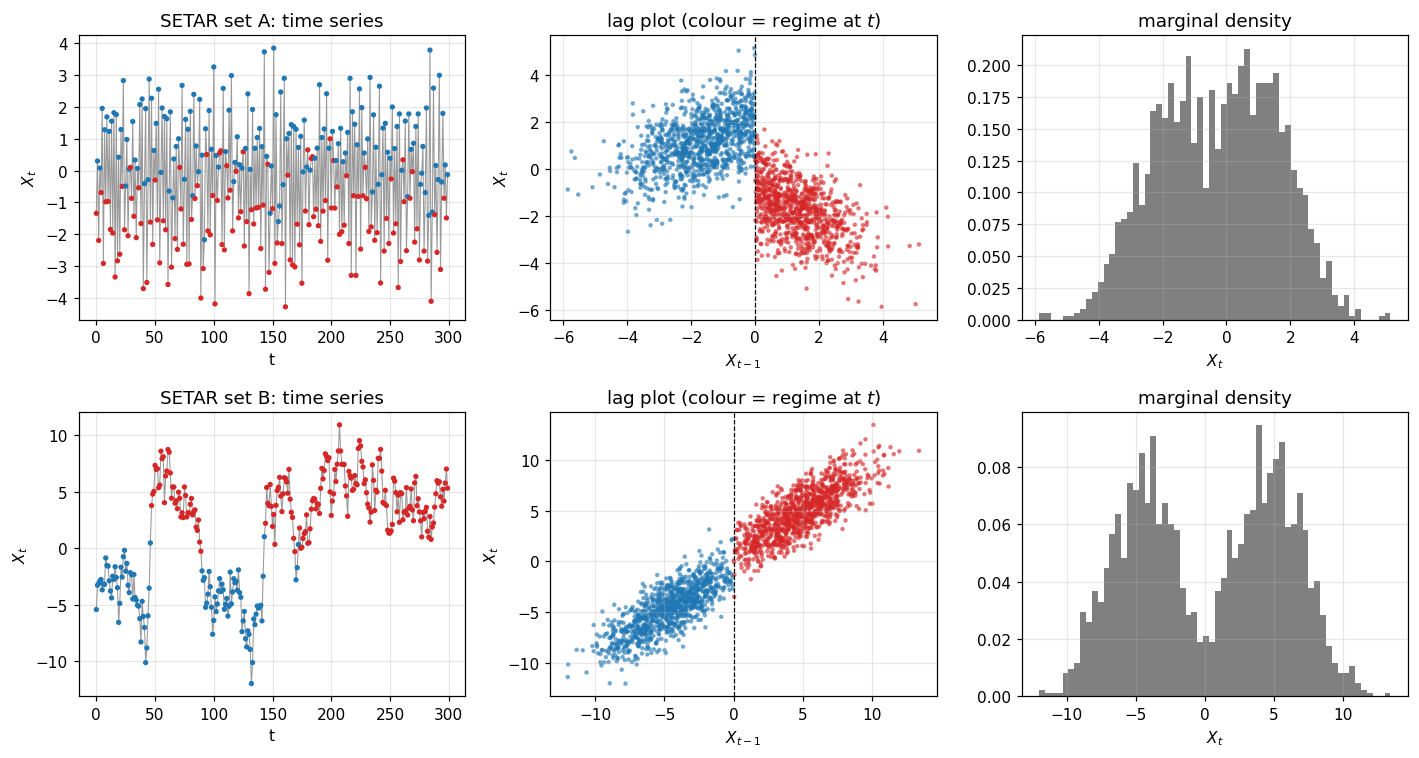

In [3]:
xA, JA = simulate_regime_ar(n, a0A, a1A, sA, setar_rule(0.0), seed=11)
xB, JB = simulate_regime_ar(n, (-1.0, 1.0), (0.8, 0.8), (1.5, 1.5), setar_rule(0.0), seed=12)
describe("SETAR set A", xA, JA)
describe("SETAR set B", xB, JB)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
three_panel(axes[0], xA, JA, "SETAR set A")
three_panel(axes[1], xB, JB, "SETAR set B")
for ax in axes[:, 1]:
    ax.axvline(0, color="k", ls="--", lw=0.8)
fig.tight_layout(); save(fig, "Images/part-1/setar.png"); plt.show()

**Skeleton / limit cycle.** Setting $\varepsilon_t=0$ gives the deterministic skeleton $x_{t}=f(x_{t-1})$.
For set A neither regime has a fixed point inside its own region ($2+0.5x=x\Rightarrow x=4>0$, and $-1-0.6x=x\Rightarrow x=-0.625\le 0$),
so the skeleton cannot settle at a point. Solving $x=f(f(x))$ with $x>0$: $x=2+0.5(-1-0.6x)=1.5-0.3x\Rightarrow x^*=1.154$, $f(x^*)=-1.692$.
The skeleton converges to the **2-cycle $\{1.154,\,-1.692\}$** – a limit cycle, which a linear AR model can never produce.
For set B the skeleton converges to $-5$ or $+5$ depending on the start value (**multiple equilibria**).

saved -> Images/part-1/setar_skeleton.png


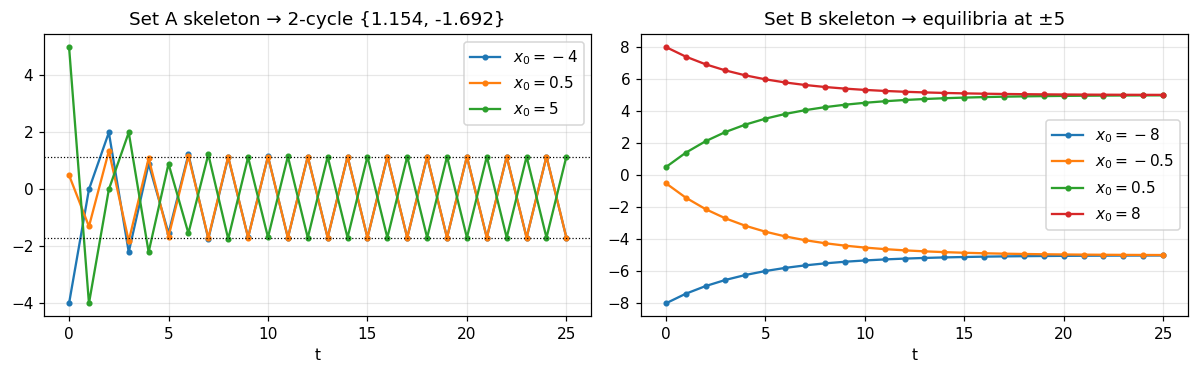

set A limit cycle: [-1.69230769  1.15384615]


In [4]:
def skeleton(x0, a0, a1, r=0.0, n=25):
    x = [x0]
    for _ in range(n):
        j = 0 if x[-1] <= r else 1
        x.append(a0[j] + a1[j] * x[-1])
    return np.array(x)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for x0 in [-4, 0.5, 5]:
    axes[0].plot(skeleton(x0, a0A, a1A), "o-", ms=3, label=f"$x_0={x0}$")
axes[0].axhline(1.1538, color="k", ls=":", lw=0.8); axes[0].axhline(-1.6923, color="k", ls=":", lw=0.8)
axes[0].set_title("Set A skeleton → 2-cycle {1.154, -1.692}"); axes[0].legend(); axes[0].set_xlabel("t")
for x0 in [-8, -0.5, 0.5, 8]:
    axes[1].plot(skeleton(x0, (-1, 1), (0.8, 0.8)), "o-", ms=3, label=f"$x_0={x0}$")
axes[1].set_title("Set B skeleton → equilibria at ±5"); axes[1].legend(); axes[1].set_xlabel("t")
fig.tight_layout(); save(fig, "Images/part-1/setar_skeleton.png"); plt.show()
print("set A limit cycle:", skeleton(0.5, a0A, a1A, n=60)[-2:])

### 1.2 IGAR(2;1)

$$X_t = a_0^{(J_t)} + a_1^{(J_t)}X_{t-1}+\varepsilon_t,\qquad P(J_t=1)=p,\ P(J_t=2)=1-p\ \text{i.i.d.}$$

Same AR coefficients as set A; we try $p=0.5$ and $p=0.9$.

Key feature: because $J_t$ is independent of $X_{t-1}$, the conditional mean is **linear**
$M(x)=p(2+0.5x)+(1-p)(-1-0.6x)$, but the conditional distribution is a two-component mixture whose
**variance depends on $x$**: $V(x)=\sigma^2+p(1-p)\big[(2-(-1))+(0.5-(-0.6))x\big]^2=1+p(1-p)(3+1.1x)^2$.
In the lag plot both regression lines are visible over the *whole* range of $X_{t-1}$ (no threshold).

IGAR p=0.5                       mean=  0.49 sd= 2.41 time in regime 1/2 = 0.50/0.50   mean run length 1/2 = 2.0/2.0
IGAR p=0.9                       mean=  2.78 sd= 2.41 time in regime 1/2 = 0.90/0.10   mean run length 1/2 = 10.0/1.1
saved -> Images/part-1/igar.png


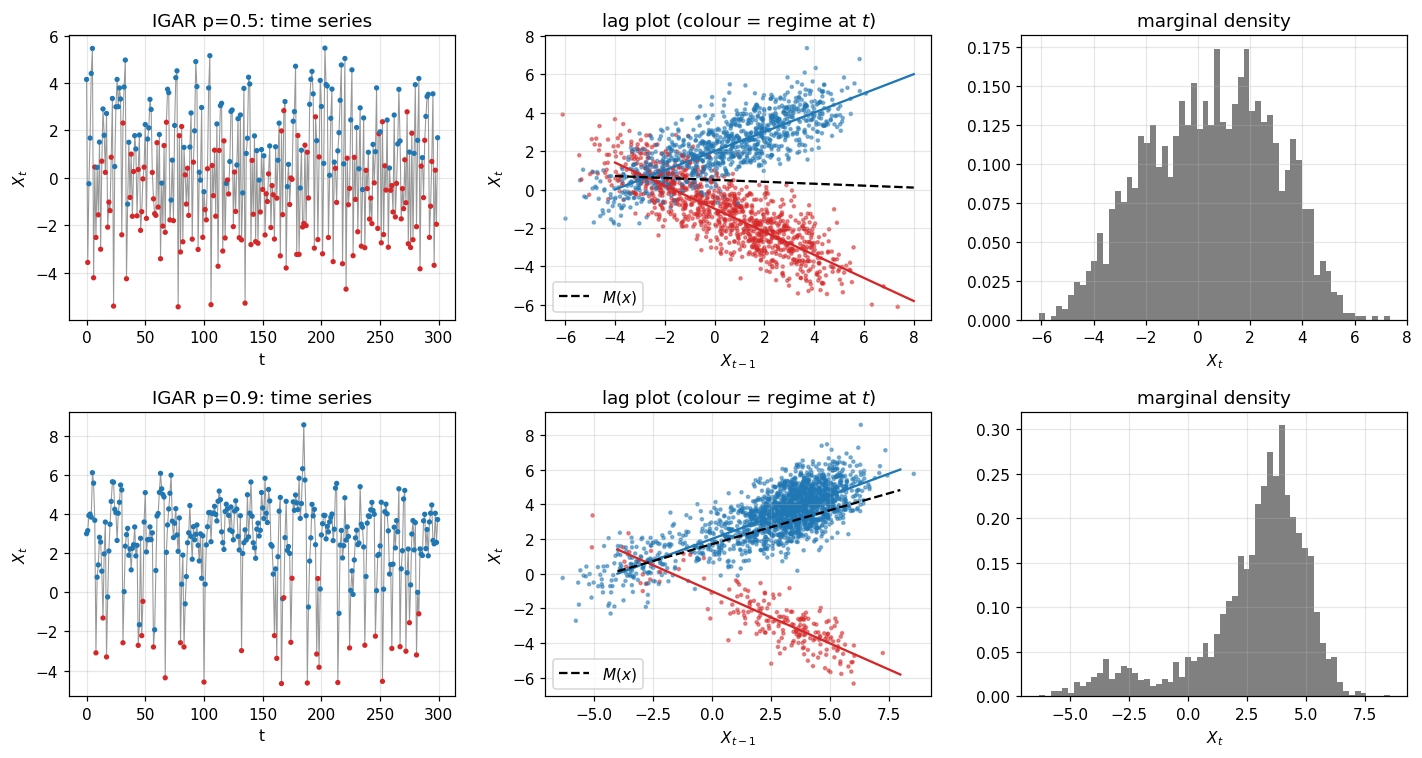

In [5]:
xI1, JI1 = simulate_regime_ar(n, a0A, a1A, sA, igar_rule(0.5), seed=21)
xI2, JI2 = simulate_regime_ar(n, a0A, a1A, sA, igar_rule(0.9), seed=22)
describe("IGAR p=0.5", xI1, JI1)
describe("IGAR p=0.9", xI2, JI2)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
three_panel(axes[0], xI1, JI1, "IGAR p=0.5")
three_panel(axes[1], xI2, JI2, "IGAR p=0.9")
xx = np.linspace(-4, 8, 50)
for ax, p in zip(axes[:, 1], [0.5, 0.9]):
    ax.plot(xx, 2 + 0.5*xx, color=C1, lw=1.5); ax.plot(xx, -1 - 0.6*xx, color=C2, lw=1.5)
    ax.plot(xx, p*(2+0.5*xx) + (1-p)*(-1-0.6*xx), "k--", lw=1.5, label="$M(x)$")
    ax.legend(loc="lower left")
fig.tight_layout(); save(fig, "Images/part-1/igar.png"); plt.show()

### 1.3 MMAR(2;1)

The regime is a hidden Markov chain, $P(J_t=j\mid J_{t-1}=i)=p_{ij}$. Same AR coefficients as set A.

* **Sticky chain** $\mathbf P_1=\begin{pmatrix}0.97&0.03\\0.05&0.95\end{pmatrix}$: stationary distribution $\pi=(0.05,0.03)/0.08=(0.625,0.375)$,
  expected sojourn times $1/0.03\approx33$ and $1/0.05=20$ steps. Long stays let the process settle near each regime's own mean
  ($2/(1-0.5)=4$ and $-1/(1+0.6)=-0.625$) ⇒ bimodal marginal distribution, level shifts in the time series.
* **Fast-switching chain** $\mathbf P_2=\begin{pmatrix}0.1&0.9\\0.9&0.1\end{pmatrix}$: $\pi=(0.5,0.5)$, regimes almost alternate.

Note: IGAR is the special case of MMAR where all rows of $\mathbf P$ are equal (no memory).

pi(P1) = [0.625 0.375]  expected sojourn: [33.33333333 20.        ]
pi(P2) = [0.5 0.5]  expected sojourn: [1.11111111 1.11111111]
MMAR sticky P1                   mean=  2.01 sd= 2.60 time in regime 1/2 = 0.61/0.39   mean run length 1/2 = 27.1/17.3
MMAR fast P2                     mean= -0.19 sd= 1.96 time in regime 1/2 = 0.50/0.50   mean run length 1/2 = 1.1/1.1
saved -> Images/part-1/mmar.png


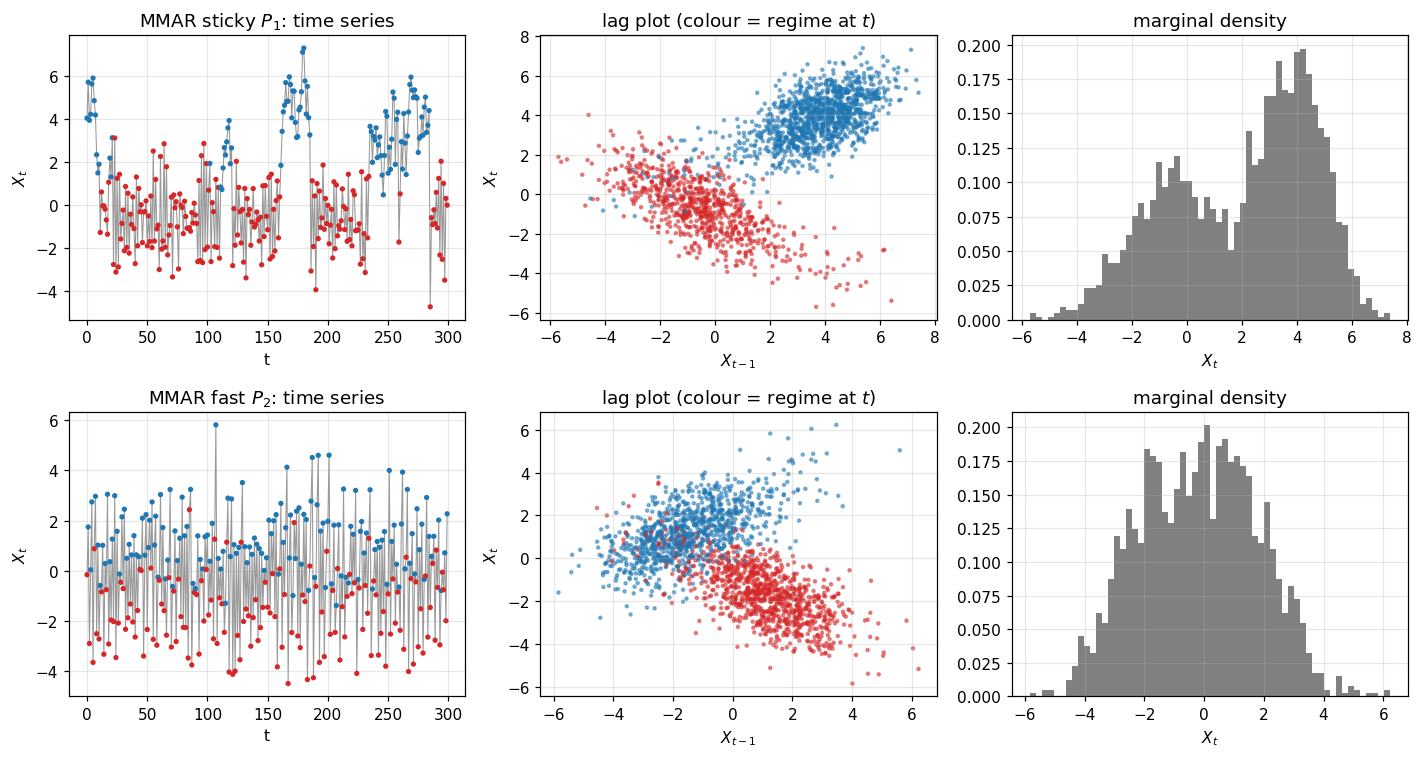

In [6]:
P1 = np.array([[0.97, 0.03], [0.05, 0.95]])
P2 = np.array([[0.10, 0.90], [0.90, 0.10]])
def stationary(P):
    w, v = np.linalg.eig(P.T)
    pi = np.real(v[:, np.argmin(abs(w - 1))]); return pi / pi.sum()
print("pi(P1) =", stationary(P1), " expected sojourn:", 1/(1-np.diag(P1)))
print("pi(P2) =", stationary(P2), " expected sojourn:", 1/(1-np.diag(P2)))

xM1, JM1 = simulate_regime_ar(n, a0A, a1A, sA, mmar_rule(P1), seed=31)
xM2, JM2 = simulate_regime_ar(n, a0A, a1A, sA, mmar_rule(P2), seed=32)
describe("MMAR sticky P1", xM1, JM1)
describe("MMAR fast P2", xM2, JM2)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
three_panel(axes[0], xM1, JM1, "MMAR sticky $P_1$")
three_panel(axes[1], xM2, JM2, "MMAR fast $P_2$")
fig.tight_layout(); save(fig, "Images/part-1/mmar.png"); plt.show()

**ACF comparison (set A coefficients).** The dependence structure differs strongly although the regime AR models are identical:
SETAR oscillates (negative lag-1 correlation), MMAR with sticky chain has slowly decaying positive ACF (level shifts).

saved -> Images/part-1/acf_compare.png


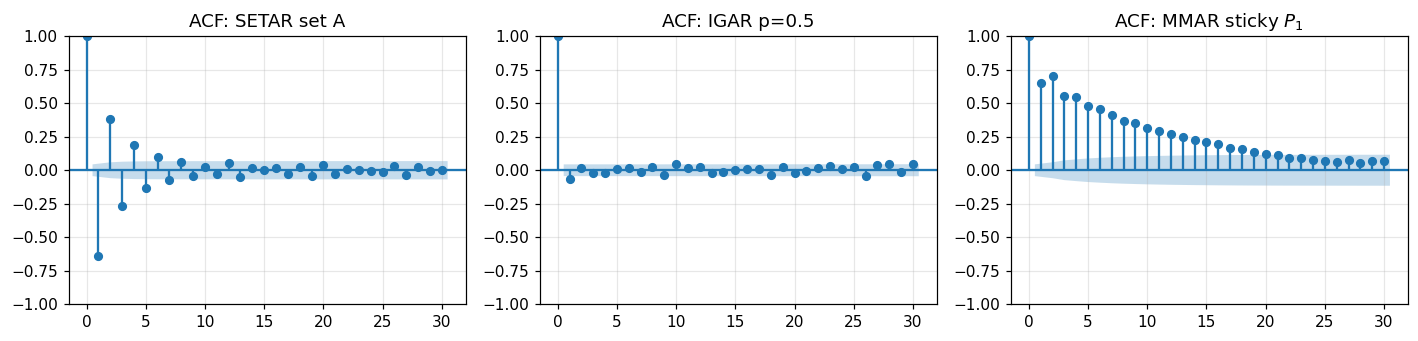

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (x, name) in zip(axes, [(xA, "SETAR set A"), (xI1, "IGAR p=0.5"), (xM1, "MMAR sticky $P_1$")]):
    plot_acf(x, lags=30, ax=ax, title="ACF: " + name)
fig.tight_layout(); save(fig, "Images/part-1/acf_compare.png"); plt.show()

## Part 2 — Conditional mean of a SETAR(2;1;1)

We use set A:
$$X_{t+1}=\begin{cases}2+0.5X_t+\varepsilon_{t+1}& X_t\le0\\-1-0.6X_t+\varepsilon_{t+1}& X_t>0\end{cases},\qquad \varepsilon\sim N(0,1).$$

**Theoretical conditional mean.** Given $X_t=x$ the regime is known and $E[\varepsilon_{t+1}\mid X_t]=0$, so

$$M(x)=E\{X_{t+1}\mid X_t=x\}=(2+0.5x)\,\mathbb 1_{\{x\le0\}}+(-1-0.6x)\,\mathbb 1_{\{x>0\}}.$$

It is piecewise linear with a **jump of size $-3$ at $x=0$**. Also $V(x)=1$ (constant).

**Estimator — local polynomial regression.** For each fitting point $x$ we solve
$$\hat\beta(x)=\arg\min_\beta\sum_{t}K\!\Big(\frac{X_{t}-x}{h}\Big)\big[X_{t+1}-\beta_0-\beta_1(X_t-x)\big]^2,\qquad \hat M(x)=\hat\beta_0(x).$$
Degree 0 = Nadaraya–Watson (local constant), degree 1 = local linear. Kernel: Epanechnikov $K(u)=\tfrac34(1-u^2)\mathbb 1_{|u|\le1}$
(also Gaussian for comparison). We also run `lowess` (tricube kernel, nearest-neighbour span = the Python analogue of R's `loess`).

In [8]:
def epan(u):  return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0.0)
def gauss(u): return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

def local_poly(x, y, x0, h, deg=1, kernel=epan, leave_out=None):
    '''Local polynomial estimate of E[y|x] at points x0.
    leave_out: array of indices (same length as x0) to exclude (for leave-one-out).'''
    x0 = np.atleast_1d(x0); out = np.full(len(x0), np.nan)
    for i, xx in enumerate(x0):
        w = kernel((x - xx) / h)
        if leave_out is not None:
            w = w.copy(); w[leave_out[i]] = 0.0
        m = w > 0
        if m.sum() < deg + 2:      # too few points in the window
            continue
        X = np.vander(x[m] - xx, deg + 1, increasing=True)   # [1, (x-x0), ...]
        XtW = X.T * w[m]
        try:
            out[i] = np.linalg.solve(XtW @ X, XtW @ y[m])[0]
        except np.linalg.LinAlgError:
            pass
    return out

def loo_cv(x, y, hs, deg=1, kernel=epan):
    '''Leave-one-out prediction errors for each bandwidth; returns matrix (n_h, n).'''
    idx = np.arange(len(x))
    return np.array([y - local_poly(x, y, x, h, deg, kernel, leave_out=idx) for h in hs])

def M_true(x):
    return np.where(x <= 0, 2 + 0.5 * x, -1 - 0.6 * x)

# 1000 simulated values of the SETAR (set A)
xs, Js = simulate_regime_ar(1000, a0A, a1A, sA, setar_rule(0.0), seed=2026)
X_prev, X_next = xs[:-1], xs[1:]
grid = np.linspace(X_prev.min(), X_prev.max(), 400)
core = (grid > np.quantile(X_prev, 0.025)) & (grid < np.quantile(X_prev, 0.975))  # avoid sparse tails in error measure
def ise(est):  # mean squared deviation from true M on the central 95% of the data
    return np.nanmean((est[core] - M_true(grid[core]))**2)
print("n pairs:", len(X_prev), " range of X_t:", X_prev.min().round(2), X_prev.max().round(2))

n pairs: 999  range of X_t: -4.68 4.37


### 2.1 Different bandwidths (local linear, Epanechnikov kernel)

Local linear, Epanechnikov:
   h= 0.10   ISE(core)=0.066
   h= 0.30   ISE(core)=0.057
   h= 0.75   ISE(core)=0.127
   h= 2.00   ISE(core)=0.362
lowess (tricube, nearest-neighbour span):
   span=0.05  ISE(core)=0.052
   span=0.20  ISE(core)=0.090
   span=0.50  ISE(core)=0.225
   span=0.90  ISE(core)=0.471
saved -> Images/part-2/bandwidths.png


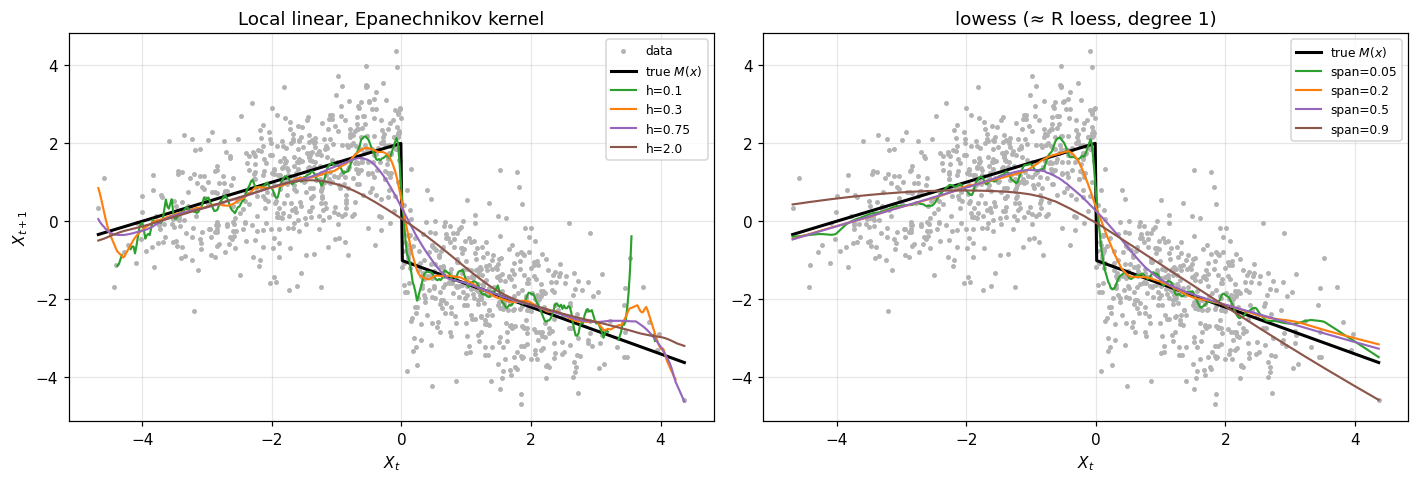

In [9]:
hs_show = [0.1, 0.3, 0.75, 2.0]
cols = ["#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.scatter(X_prev, X_next, s=5, color="0.7", label="data")
ax.plot(grid, M_true(grid), "k", lw=2, label="true $M(x)$")
print("Local linear, Epanechnikov:")
for h, c in zip(hs_show, cols):
    est = local_poly(X_prev, X_next, grid, h, deg=1)
    ax.plot(grid, est, color=c, lw=1.4, label=f"h={h}")
    print(f"   h={h:5.2f}   ISE(core)={ise(est):.3f}")
ax.set_xlabel("$X_t$"); ax.set_ylabel("$X_{t+1}$"); ax.set_title("Local linear, Epanechnikov kernel")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(X_prev, X_next, s=5, color="0.7")
ax.plot(grid, M_true(grid), "k", lw=2, label="true $M(x)$")
print("lowess (tricube, nearest-neighbour span):")
for f, c in zip([0.05, 0.2, 0.5, 0.9], cols):
    lw_ = lowess(X_next, X_prev, frac=f, it=0, return_sorted=True)
    ax.plot(lw_[:, 0], lw_[:, 1], color=c, lw=1.4, label=f"span={f}")
    print(f"   span={f:4.2f}  ISE(core)={ise(np.interp(grid, lw_[:,0], lw_[:,1])):.3f}")
ax.set_xlabel("$X_t$"); ax.set_title("lowess (≈ R loess, degree 1)"); ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "Images/part-2/bandwidths.png"); plt.show()

### 2.2 Bandwidth selection by leave-one-out cross-validation

$$CV(h)=\frac1N\sum_t\big(X_{t+1}-\hat M_{-t}(X_t;h)\big)^2,$$
where $\hat M_{-t}$ is fitted without observation $t$. (Without leaving out, $h\to0$ would interpolate the data and always "win".)
We compare Nadaraya–Watson (degree 0) and local linear (degree 1) and both kernels.

points used in CV (finite for all h): 984 of 999
NW, Epanechnikov  : h_opt = 0.15   CV(h_opt) = 1.029
LL, Epanechnikov  : h_opt = 0.20   CV(h_opt) = 1.034
LL, Gaussian      : h_opt = 0.20   CV(h_opt) = 1.030
NW, Epanechnikov  : ISE(core) at h_opt = 0.056
LL, Epanechnikov  : ISE(core) at h_opt = 0.054
LL, Gaussian      : ISE(core) at h_opt = 0.051
saved -> Images/part-2/loo_cv.png


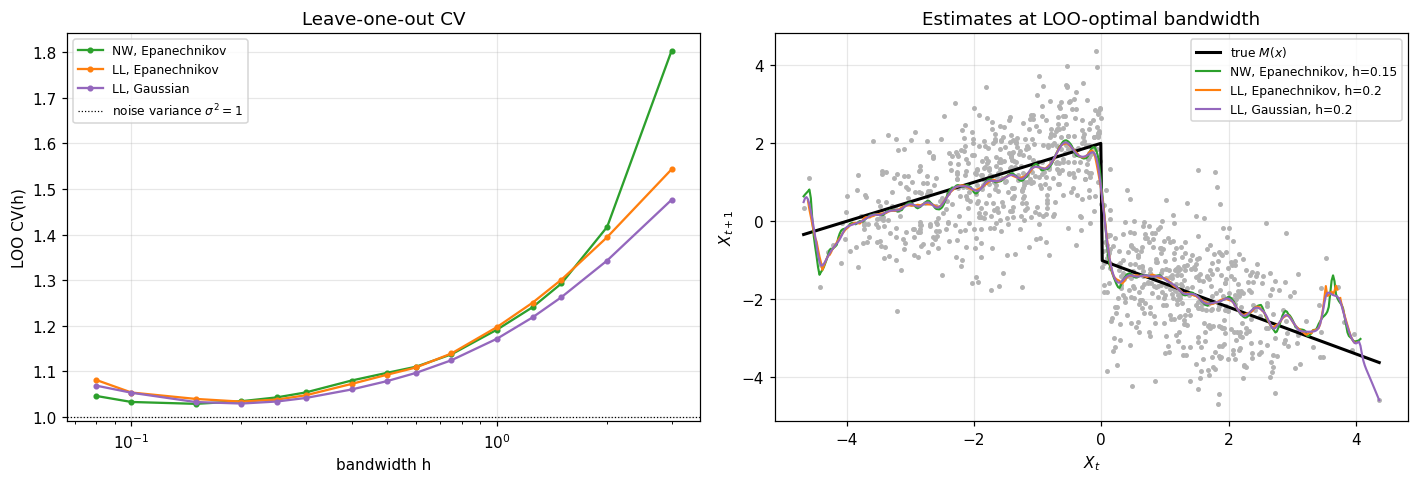

In [10]:
hs = np.array([0.08, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0])
res = {}
for name, deg, ker, hscale in [("NW, Epanechnikov", 0, epan, 1), ("LL, Epanechnikov", 1, epan, 1),
                               ("LL, Gaussian", 1, gauss, 1/np.sqrt(5))]:
    # Gaussian sd scaled by 1/sqrt(5) so it has the same kernel variance as the Epanechnikov with the same h
    R = loo_cv(X_prev, X_next, hs * hscale, deg, ker)
    res[name] = (R, deg, ker, hscale)
ok = np.all([np.all(np.isfinite(r[0]), axis=0) for r in res.values()], axis=0)   # common set of points
print(f"points used in CV (finite for all h): {ok.sum()} of {len(ok)}")
cv = {k: np.mean(v[0][:, ok]**2, axis=1) for k, v in res.items()}
hopt = {k: hs[np.argmin(c)] for k, c in cv.items()}
for k in cv:
    print(f"{k:18s}: h_opt = {hopt[k]:.2f}   CV(h_opt) = {cv[k].min():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for k, c in zip(cv, cols):
    ax.plot(hs, cv[k], "o-", ms=3, color=c, label=k)
ax.axhline(1.0, color="k", ls=":", lw=0.8, label="noise variance $\\sigma^2=1$")
ax.set_xscale("log"); ax.set_xlabel("bandwidth h"); ax.set_ylabel("LOO CV(h)")
ax.set_title("Leave-one-out CV"); ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(X_prev, X_next, s=5, color="0.7")
ax.plot(grid, M_true(grid), "k", lw=2, label="true $M(x)$")
for (k, (R, deg, ker, sc)), c in zip(res.items(), cols):
    est = local_poly(X_prev, X_next, grid, hopt[k] * sc, deg, ker)
    ax.plot(grid, est, color=c, lw=1.4, label=f"{k}, h={hopt[k]}")
    print(f"{k:18s}: ISE(core) at h_opt = {ise(est):.3f}")
ax.set_xlabel("$X_t$"); ax.set_ylabel("$X_{t+1}$"); ax.set_title("Estimates at LOO-optimal bandwidth"); ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "Images/part-2/loo_cv.png"); plt.show()

**Findings (Part 2).**
* Small $h$: low bias, the jump at 0 is reproduced sharply, but the estimate is very wiggly (high variance), especially in the sparse tails.
* Large $h$: smooth, low variance, but the jump is smeared over a wide interval and the curve is biased towards the overall mean ($h\to\infty$ gives a global straight line for local linear / a constant for NW).
* LOO-CV balances the two; the optimum is a fairly small bandwidth because the true function has a discontinuity.
  CV(h_opt) is close to $\sigma^2=1$, as it should be (the irreducible noise).
* Local linear has less bias than NW near the boundaries of the data (NW is biased towards the interior at the edges); the kernel type matters much less than the bandwidth.
* Kernel smoothers assume a smooth $M$; they can never reproduce the discontinuity exactly — the error concentrates in a window of width $\approx h$ around $x=0$.